In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
path = 'data/Mall_Customers.csv'

In [3]:
df = pd.read_csv(path)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


- Gender: Giới tính
- Age: Độ tuổi
- Annual Income: thu thập hàng năm
- Spending Score: Điểm chi tiêu

In [4]:
df = df.drop(["CustomerID"], axis=1)

In [5]:
df.shape

(200, 4)

### EDA

In [6]:
print("Số lượng giá trị thiếu trong từng cột:")
print(df.isnull().sum())

Số lượng giá trị thiếu trong từng cột:
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


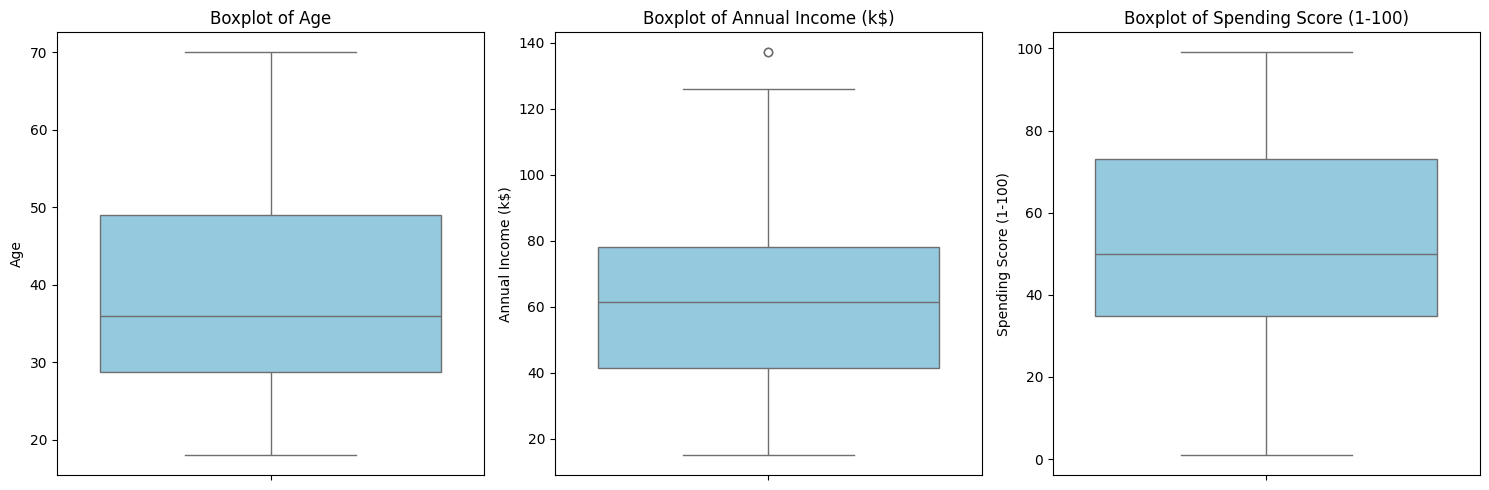

In [7]:
plt.figure(figsize=(15, 5))

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

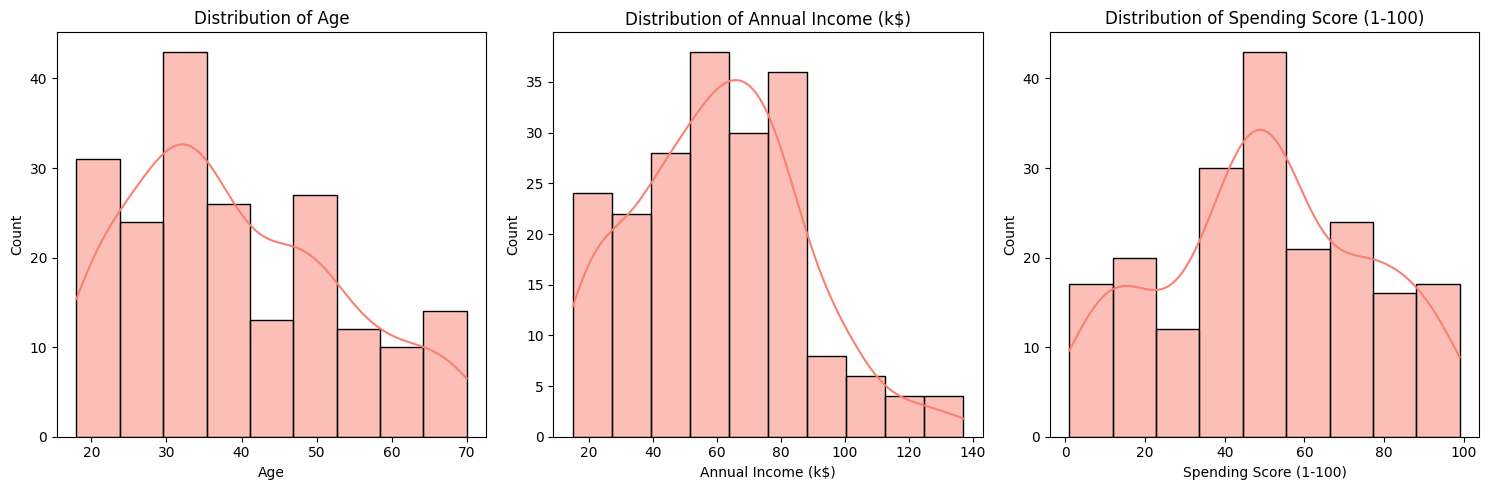

In [8]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='salmon')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

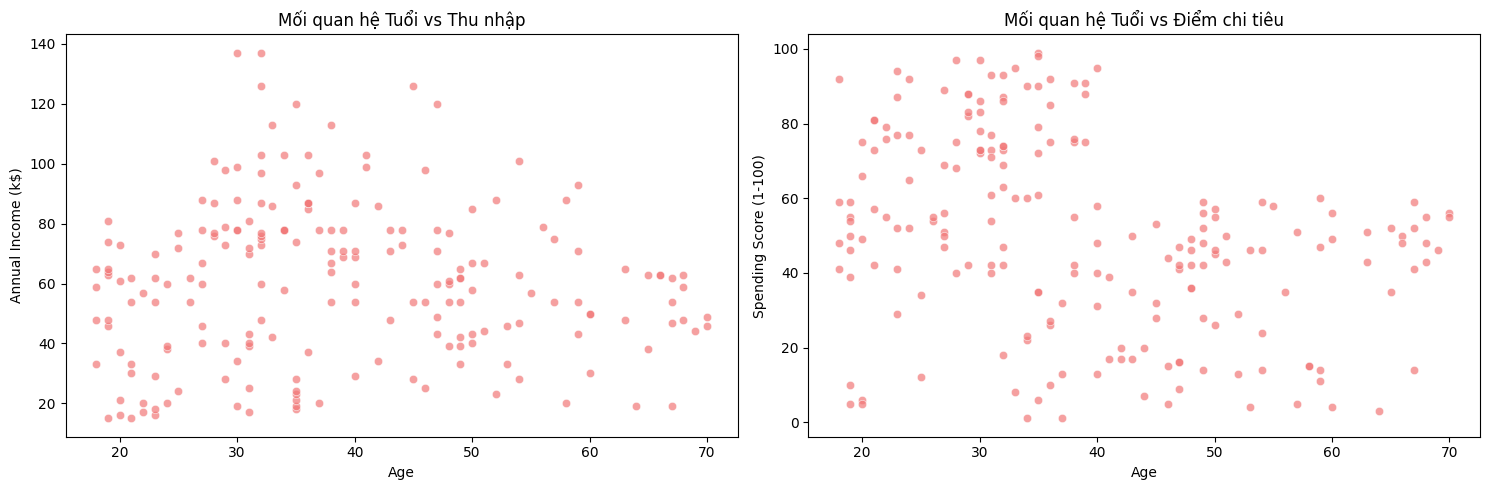

In [9]:
plt.figure(figsize=(15, 5))

# 1. Age vs Annual Income
plt.subplot(1, 2, 1)
sns.scatterplot(x='Age', y='Annual Income (k$)', data=df, color='#f17878', alpha=0.7)
plt.title('Mối quan hệ Tuổi vs Thu nhập')

# 2. Age vs Spending Score
plt.subplot(1, 2, 2)
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df, color='#f17878', alpha=0.7)
plt.title('Mối quan hệ Tuổi vs Điểm chi tiêu')

plt.tight_layout()
plt.show()

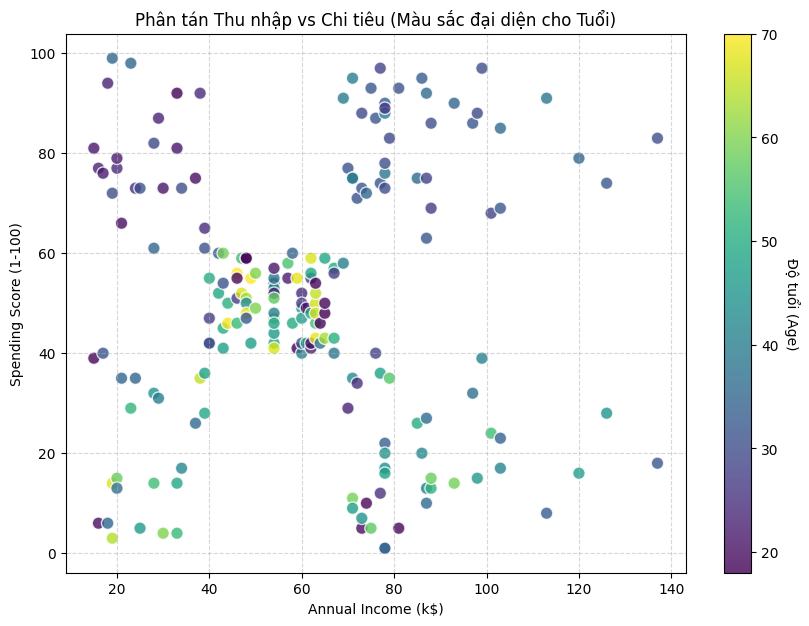

In [10]:
plt.figure(figsize=(10, 7))

# Vẽ biểu đồ Income vs Spending, nhưng dùng màu sắc để biểu thị Age
scatter = plt.scatter(df['Annual Income (k$)'], 
                      df['Spending Score (1-100)'], 
                      c=df['Age'],                # Màu sắc thay đổi theo tuổi
                      cmap='viridis',             # Bảng màu từ tím đến vàng
                      alpha=0.8, 
                      edgecolors='w', 
                      s=80)                       # Kích thước điểm

# Thêm thanh màu (colorbar) để biết màu nào ứng với tuổi nào
cbar = plt.colorbar(scatter)
cbar.set_label('Độ tuổi (Age)', rotation=270, labelpad=15)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Phân tán Thu nhập vs Chi tiêu (Màu sắc đại diện cho Tuổi)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

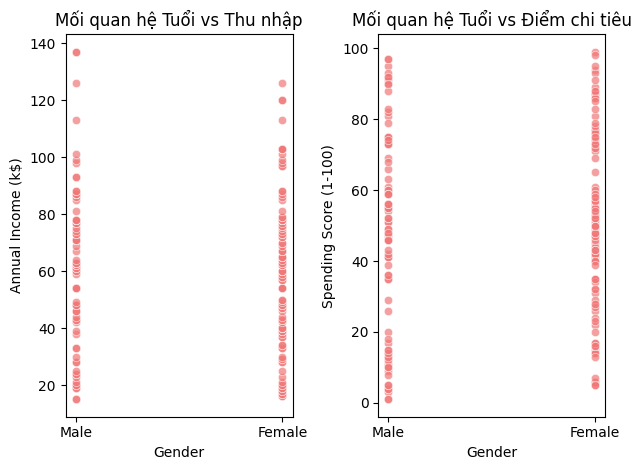

In [11]:
# 1. Gender vs Annual Income
plt.subplot(1, 2, 1)
sns.scatterplot(x='Gender', y='Annual Income (k$)', data=df, color='#f17878', alpha=0.7)
plt.title('Mối quan hệ Tuổi vs Thu nhập')

# 2. Gender vs Spending Score
plt.subplot(1, 2, 2)
sns.scatterplot(x='Gender', y='Spending Score (1-100)', data=df, color='#f17878', alpha=0.7)
plt.title('Mối quan hệ Tuổi vs Điểm chi tiêu')

plt.tight_layout()
plt.show()

In [12]:
print("Thống kê mô tả dữ liệu:")
display(df[features].describe().round(2))

Thống kê mô tả dữ liệu:


,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00
mean,38.85,60.56,50.20
std,13.97,26.26,25.82
min,18.00,15.00,1.00
25%,28.75,41.50,34.75
50%,36.00,61.50,50.00
75%,49.00,78.00,73.00
max,70.00,137.00,99.00


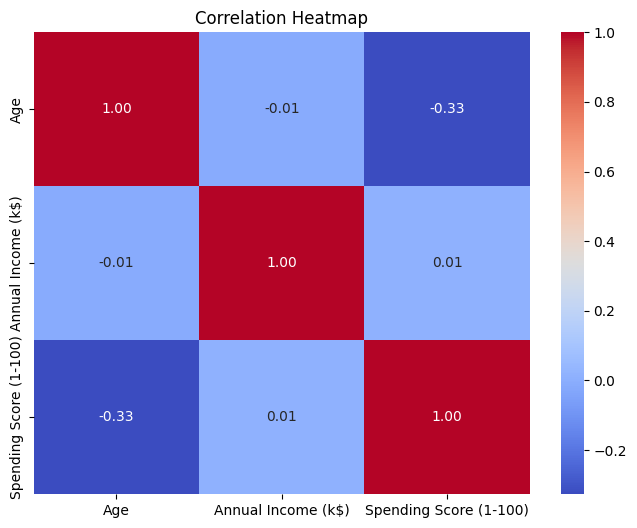

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Data clearn

In [14]:
df = df.dropna()
df = df.drop_duplicates()
df.shape

(200, 4)

### Data Processing

In [15]:
class MyStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        
    def fit(self, X):
        X_array = np.asarray(X)
        # Tính trung bình và độ lệch chuẩn theo từng cột
        self.mean_ = np.mean(X_array, axis=0)
        self.std_ = np.std(X_array, axis=0)
        # Tránh lỗi khi chia cho 0
        self.std_[self.std_==0] = 1e-9
        return self
        
    def transform(self, X):
        X_array = np.asarray(X)
        # Áp dụng công thức: (X - mean) / std
        return (X_array - self.mean_) / self.std_
         
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [16]:
features = ['Annual Income (k$)', 'Spending Score (1-100)']


scaler = MyStandardScaler()
df[features] = scaler.fit_transform(df[features])

In [17]:
df[features].describe().round(2)

,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00
mean,-0.00,-0.00
std,1.00,1.00
min,-1.74,-1.91
25%,-0.73,-0.60
50%,0.04,-0.01
75%,0.67,0.89
max,2.92,1.89


In [18]:
X = df[features].values

### K-Means Scratch

#### 1. Mục tiêu
- Mục tiêu toán học: tối thiểu hóa tổng bình phương khoảng cách từ mỗi điểm đến trọng tâm (centroid) của cụm mà nó thuộc về, Hàm mục tiêu (SSE - Sum of Squared Errors):
$$J = \sum^k_{j=1} \sum_{x_i \in C_j} ||x_i - \mu_j||^2$$

- trong đó:
    - $C_j$ là tập hợp các điểm thuộc cụm thứ j
    - $\mu_j = \frac {1} {|C_j|} \sum_{x_i \in C_j} x_i$ là centroid (trọng tâm) của cụm j
    - ||.|| thường là chuẩn Euclidean $||x - y|| = \sqrt{\sum^d_{t=1} (x_t - y_t)^2}$

#### 2. Ý nghĩa hình học
- Mỗi cụm được đại diện bởi centroid – “trung bình cộng” của tất cả các điểm trong cụm.
- Hàm $J$ đo độ “phân tán” nội tại cụm. Càng nhỏ, các điểm càng quây quần quanh centroid của chúng.

#### 3. Thuật toán K-means (phương pháp Lloyd)
- Vì tối ưu chính xác $J$ là NP-khó, K-means sử dụng một heuristic lặp, hội tụ đến cực trị địa phương.

- Các bước lặp:
    - 1. Khởi tạo - Chọn $k$ centroid ban đầu (thường là chọn ngẫu nhiên k điểm từ dữ liệu)
    - 2. Gán cụm (Assignment) - mỗi điểm $x_i$ được gán vào cụm có centroid gần nhất: $$label(x_i) = arg min_{j \in \{1, ..., k\}} ||x_i - \mu_j||^2$$

    - 3. Cập nhật centroid (Update) – tính lại centroid cho mỗi cụm dựa trên các điểm vừa được gán: $$\mu_j^{(new) }= \frac {1} {|C_j|} \sum_{x_i \in C_j} x_i$$

    - 4. Lặp lại bước 2–3 cho đến khi centroid không thay đổi (hoặc thay đổi rất nhỏ) hoặc đủ số lần lặp.

In [19]:
class KMeansScratch:
    def __init__(self, n_clusters=5, max_iter=300):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None
        self.labels = None

    def fit(self, X):
        # Khởi tạo tâm cụm bằng cách chọn ngẫu nhiên các điểm từ X
        idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[idx]

        for _ in range(self.max_iter):
            # Gán cụm
            # Tính khoảng cách từ mỗi điểm đến tất cả các centroids
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            new_labels = np.argmin(distances, axis=1)

            # Kiểm tra hội tụ (Nếu nhãn không đổi thì dừng)
            if self.labels is not None and np.all(new_labels == self.labels):
                break
            
            self.labels = new_labels
            # Cập nhật centroids
            new_centroids = np.array([X[self.labels == i].mean(axis=0) 
                                     if len(X[self.labels == i]) > 0 
                                     else self.centroids[i] # Giữ nguyên nếu cụm trống
                                     for i in range(self.n_clusters)])
        
            self.centroids = new_centroids
        pass
    
    def predict(self, X_new):
        distances = np.linalg.norm(X_new[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

In [20]:
model = KMeansScratch(n_clusters=5)
model.fit(X)
labels = model.labels

df['Cluster_custom'] = labels

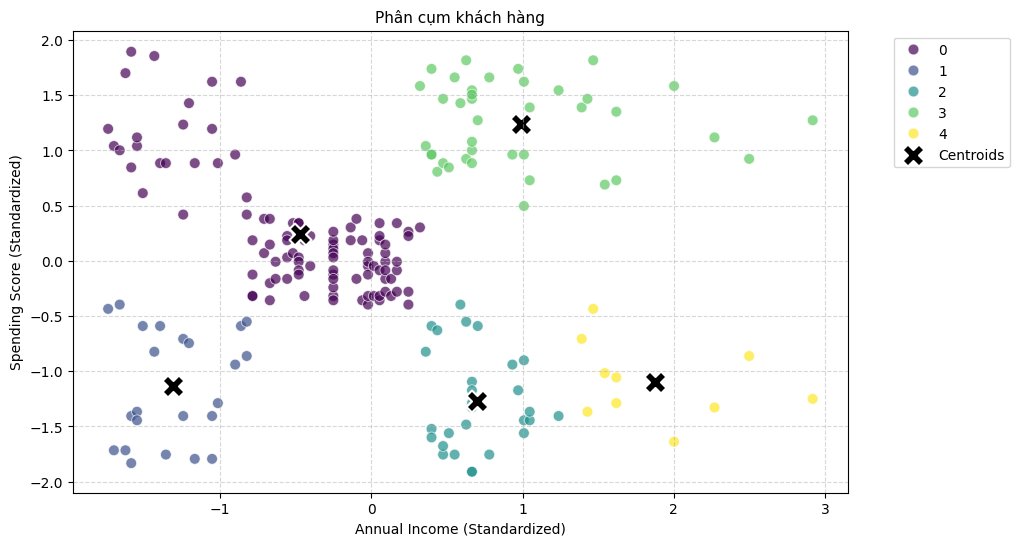

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster_custom'],
    palette='viridis',
    s=60,
    alpha=0.7
)

plt.scatter(
    model.centroids[:, 0], 
    model.centroids[:, 1], 
    s=250,          
    c='black',      
    marker='X',     
    edgecolors='white', 
    linewidths=1.5,
    label='Centroids'
)

plt.title('Phân cụm khách hàng', fontsize=11)
plt.xlabel('Annual Income (Standardized)')
plt.ylabel('Spending Score (Standardized)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [22]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

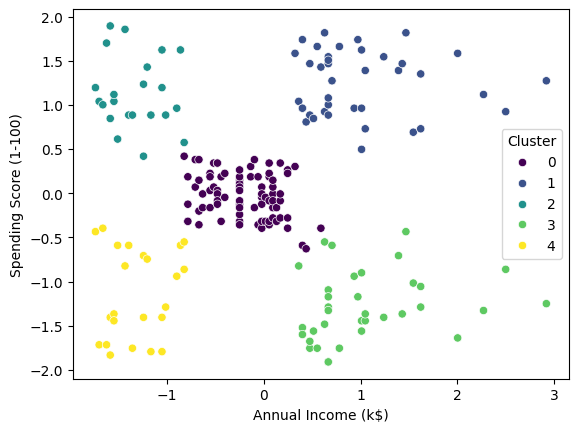

In [23]:
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)

In [24]:
def silhouette_score_scratch(X, labels):
    n = len(X)
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2: return 0
    
    scores = []
    for i in range(n):
        # a(i): Khoảng cách trung bình đến các điểm cùng cụm
        same_cluster = X[labels == labels[i]]
        if len(same_cluster) > 1:
            a = np.mean(np.linalg.norm(same_cluster - X[i], axis=1)) * (len(same_cluster) / (len(same_cluster) - 1))
        else:
            a = 0
            
        # b(i): Khoảng cách trung bình đến các điểm ở cụm gần nhất khác
        b = float('inf')
        for label in unique_labels:
            if label == labels[i]: continue
            other_cluster = X[labels == label]
            avg_dist_other = np.mean(np.linalg.norm(other_cluster - X[i], axis=1))
            b = min(b, avg_dist_other)
            
        # Tính s(i)
        s = (b - a) / max(a, b) if max(a, b) > 0 else 0
        scores.append(s)
        
    return np.mean(scores)

In [25]:
labels = model.labels
centroids = model.centroids

s_score = silhouette_score_scratch(X, labels)

print(f"Silhouette Score: {s_score:.4f}")

Silhouette Score: 0.4645


### K-medoids from scratch

In [26]:
class KMedoidsScratch:
    def __init__(self, k=5, max_iter=300):
        self.k = k
        self.max_iter = max_iter
        self.medoids = None
        self.labels = None

    def _get_distances(self, X, medoids):
        """Tính toán ma trận khoảng cách từ các điểm đến các medoids"""
        # Sử dụng Manhattan Distance (L1)
        return np.linalg.norm(X[:, np.newaxis] - medoids, ord=1, axis=2)

    def fit(self, X):
        n_samples = X.shape[0]
        
        # 1. Khởi tạo: Chọn ngẫu nhiên K điểm từ tập dữ liệu làm Medoids ban đầu
        idx = np.random.choice(n_samples, self.k, replace=False)
        self.medoids = X[idx]
        
        for _ in range(self.max_iter):
            # 2. Gán nhãn cho mỗi điểm dựa trên medoid gần nhất
            distances = self._get_distances(X, self.medoids)
            new_labels = np.argmin(distances, axis=1)
            
            # Nếu không có sự thay đổi nhãn, thuật toán hội tụ
            if self.labels is not None and np.all(new_labels == self.labels):
                break
            self.labels = new_labels
            
            # 3. Cập nhật Medoids: Trong mỗi cụm, tìm điểm làm tối thiểu hóa tổng khoảng cách
            new_medoids = np.copy(self.medoids)
            for i in range(self.k):
                cluster_points = X[self.labels == i]
                if len(cluster_points) > 0:
                    # Tính tổng khoảng cách từ mỗi điểm trong cụm đến tất cả các điểm khác trong cùng cụm
                    # Điểm nào có tổng khoảng cách nhỏ nhất sẽ là Medoid mới
                    dist_matrix = np.linalg.norm(cluster_points[:, np.newaxis] - cluster_points, ord=1, axis=2)
                    total_costs = np.sum(dist_matrix, axis=1)
                    best_medoid_idx = np.argmin(total_costs)
                    new_medoids[i] = cluster_points[best_medoid_idx]
            
            self.medoids = new_medoids

    def predict(self, X_new):
        distances = self._get_distances(X_new, self.medoids)
        return np.argmin(distances, axis=1)

In [27]:
model = KMedoidsScratch(k=5)
model.fit(X)
labels = model.labels

df['KMedoids_Cluster_custom'] = labels

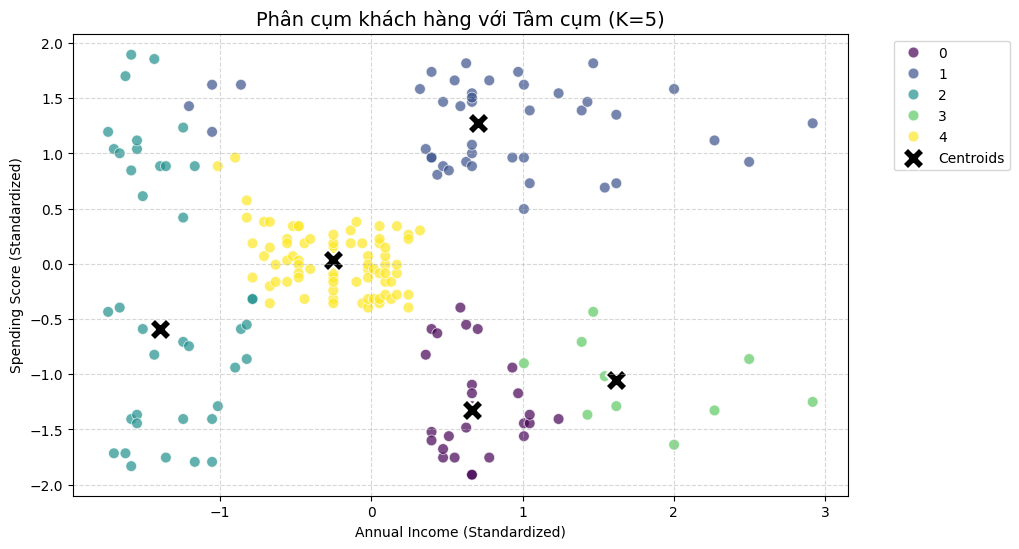

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['KMedoids_Cluster_custom'],
    palette='viridis',
    s=60,
    alpha=0.7
)

plt.scatter(
    model.medoids[:, 0], 
    model.medoids[:, 1], 
    s=250,  
    c='black',
    marker='X',      
    edgecolors='white', 
    linewidths=1.5,
    label='Centroids'
)

plt.title('Phân cụm khách hàng với Tâm cụm (K=5)', fontsize=14)
plt.xlabel('Annual Income (Standardized)')
plt.ylabel('Spending Score (Standardized)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### DBSCAN from scratch

### Hierarchical clustering from scratch